# Introduction



## Problem Statement

Although extensive public data exist on poverty, educational attainment, unemployment, and population, these indicators are frequently stored in siloed systems and analyzed independently. This fragmentation limits the ability of public institutions—particularly those in rural regions—to conduct integrated, county-level assessments of regional need. As a result, many communities lack the analytic capacity to derive actionable insights that could inform local policy, educational programming, or economic development strategies.

**During preliminary modeling and exploratory data analysis (EDA), it became evident that the original focus on the 13 counties in North Central Arkansas (NCA) would not yield the statistical variance necessary to support meaningful clustering or predictive modeling.** The spread of key indicators—especially educational attainment and poverty rates—was too narrow across the NCA region to form clearly distinct groupings or uncover deeper structural patterns. To address this, the scope was expanded to include **all 75 Arkansas counties**, enabling a broader comparative analysis while preserving the original intent of highlighting regional disparities and development potential within the NCA subset.

The core data challenge is *twofold*:

1. **Pattern Identification:** Can we identify meaningful patterns and disparities in educational and economic conditions across counties in Arkansas, with specific attention to regional differences?
2. **Predictive Insight:** Can machine learning models be used to forecast future outcomes or classify counties based on shared vulnerabilities or developmental potential?

Addressing this challenge requires aggregating and standardizing multiple publicly available datasets, performing exploratory data analysis (EDA) to uncover relationships, and applying basic predictive modeling techniques to generate deeper insights. These insights can support more data-informed curriculum design, targeted workforce development programs, and competitive grant applications aligned with regional priorities.

## Section 1:  Work environment set up

In [1]:
# --- Standard Imports ---
import pandas as pd
import numpy as np
import warnings
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys

from pathlib import Path
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Custom Imports ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Setup ---
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# --- Paths ---
data_dir = Path("data")
output_dir = Path("ar_outputs")
output_dir.mkdir(exist_ok=True)
figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

log_dir = Path("ar_logs")
log_dir.mkdir(exist_ok=True)

image_dir = Path("ar_outputs/images")
image_dir.mkdir(parents=True, exist_ok=True)

# Clear existing handlers
logging.getLogger().handlers.clear()

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_dir / "project.log", mode='w', encoding='utf-8'),
        logging.StreamHandler(sys.stdout)
    ]
)

# --- Global Color Mapping for Key Variables (Percentages) ---
variable_colors = {
    "BachelorsDegreePct": "#1f77b4",   # Blue
    "HighSchoolGradPct": "#2ca02c",    # Green
    "PovertyRate": "#ff7f0e",          # Orange
    "UnemploymentRate": "#d62728"      # Red
}

print("Environment ready. Paths and logging configured.")



Environment ready. Paths and logging configured.


# Section 2: Load and prepare Data sets

## Section 2.1: Load utility functions and national datasets ----

In [2]:
# Section 2A: Load utility functions and national datasets ----

# Import custom utility functions
from utils import (
    standardize_column_names,
    extract_key_indicators,
    filter_to_county_level,
    log_duplicate_attributes,
    clean_and_extract_year,
    nca_counties
)

data_dir = Path("data")
complete_dir = data_dir / "complete_sets"

complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}


# Load, clean, and extract year from each dataset
complete_data = {}

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        logging.info(f" {key} columns after cleaning: {df.columns.tolist()}")
        df = filter_to_county_level(df)
        df = clean_and_extract_year(df)

        # Rename fields if necessary
        df.rename(columns={'area_name': 'county'}, inplace=True)

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f"Loaded {filename}: {df.shape[0]} rows")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


# Confirmation message
logging.info("Utility functions from utils.py loaded successfully.")


2025-07-22 14:50:15,655 [INFO] Utility functions loaded from updated utils.py
2025-07-22 14:50:15,763 [INFO]  edu columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-22 14:50:16,154 [WARNING] edu has duplicate county-attribute pairs.
2025-07-22 14:50:16,155 [INFO] Loaded Education2023.csv: 169245 rows
2025-07-22 14:50:16,239 [INFO]  pop columns after cleaning: ['fipstxt', 'state', 'area_name', 'attribute', 'value']
2025-07-22 14:50:16,590 [WARNING] pop has duplicate county-attribute pairs.
2025-07-22 14:50:16,591 [INFO] Loaded PopulationEstimates.csv: 205108 rows
2025-07-22 14:50:16,624 [INFO]  poverty columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-22 14:50:16,751 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-22 14:50:16,751 [INFO] Loaded Poverty2023.csv: 79961 rows
2025-07-22 14:50:16,872 [INFO]  unemp columns after cleaning: ['fips_code', 'state', 'area_name', 'attribute', 'value']
20

## Section 2.2: Load and process national datasets

In [3]:
# Section 2.2: Load and process national datasets

complete_dir = data_dir / "complete_sets"
complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}

state_lookup = None

# Choose your analysis year here
selected_year = '2023'

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        # Load and standardize
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        df = filter_to_county_level(df)
        df.rename(columns={'area_name': 'county', 'fips_code': 'fips', 'fipstxt': 'fips'}, inplace=True)
        df['county'] = df['county'].str.strip().str.lower()

        # Extract year from attribute
        if 'attribute' in df.columns:
            df = clean_and_extract_year(df)

            # Only filter datasets where year tagging applies
            if key in ['pop', 'poverty', 'unemp']:
                df = df[df['attribute_year'] == selected_year]

        # Save state info once from education
        if key == 'edu':
            state_lookup = df[['county', 'state']].drop_duplicates().copy()
            state_lookup['county'] = state_lookup['county'].str.lower().str.strip()
            state_lookup['state'] = state_lookup['state'].str.upper().str.strip()

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f" Loaded and processed {filename} with year filter: {selected_year if key != 'edu' else 'N/A'}")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


2025-07-22 14:50:18,032 [WARNING] edu has duplicate county-attribute pairs.
2025-07-22 14:50:18,036 [INFO]  Loaded and processed Education2023.csv with year filter: N/A
2025-07-22 14:50:18,495 [WARNING] pop has duplicate county-attribute pairs.
2025-07-22 14:50:18,499 [INFO]  Loaded and processed PopulationEstimates.csv with year filter: 2023
2025-07-22 14:50:18,664 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-22 14:50:18,667 [INFO]  Loaded and processed Poverty2023.csv with year filter: 2023
2025-07-22 14:50:19,429 [INFO]  Loaded and processed Unemployment2023.csv with year filter: 2023


## Section 2.3: Subset Arkansas 

In [4]:
# Section 2.3 – Create Arkansas-Wide Dataset
# -------------------------------------------

# Function to subset and clean Arkansas counties (no NCA filtering)
def get_ar_subset(df, dataset_name):
    df = df.copy()
    df = df[df['state'].str.upper() == 'AR']
    df['county'] = (
        df['county']
        .str.replace(" county", "", regex=False)
        .str.replace(", ar", "", regex=False)
        .str.strip()
        .str.lower()
    )
    logging.info(f"{dataset_name.upper()} → AR rows: {df.shape[0]}")
    return df

# Get AR-wide subsets
edu_ar = get_ar_subset(complete_data['edu'], 'edu')
poverty_ar = get_ar_subset(complete_data['poverty'], 'poverty')
unemp_ar = get_ar_subset(complete_data['unemp'], 'unemp')
pop_ar = get_ar_subset(complete_data['pop'], 'pop')

# Pivot to wide format
edu_wide_ar = edu_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
poverty_wide_ar = poverty_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
unemp_wide_ar = unemp_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
pop_wide_ar = pop_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')

# Merge datasets
df_ar = reduce(
    lambda left, right: pd.merge(left, right, on='county', how='outer'),
    [edu_wide_ar, poverty_wide_ar, unemp_wide_ar, pop_wide_ar]
)

# Flatten column names
df_ar.columns = [col if isinstance(col, str) else col[1] for col in df_ar.columns]

# Save raw merged data
df_ar.to_csv(output_dir / f"ar_dataset_cleaned_{selected_year}.csv")
logging.info(f"AR final dataset saved: ar_dataset_cleaned_{selected_year}.csv")
print(f"AR dataset ready with shape: {df_ar.shape}")


2025-07-22 14:50:19,480 [INFO] EDU → AR rows: 3948
2025-07-22 14:50:19,487 [INFO] POVERTY → AR rows: 457
2025-07-22 14:50:19,492 [INFO] UNEMP → AR rows: 450
2025-07-22 14:50:19,512 [INFO] POP → AR rows: 1275
2025-07-22 14:50:19,578 [INFO] AR final dataset saved: ar_dataset_cleaned_2023.csv
AR dataset ready with shape: (75, 83)


## Section 2.5 Streamline AR data set 

In [5]:
# Section 2.7 – Finalize Arkansas Dataset

print("Columns BEFORE renaming (AR):")
print(df_ar.columns.tolist())

# Ensure 'county' is a column, not index
df_ar = df_ar.reset_index()

# Rename long education/population columns
df_ar = df_ar.rename(columns={
    "percent of adults who are high school graduates (or equivalent), 2019-23": "HighSchoolGradRate",
    "percent of adults with a bachelor's degree or higher, 2019-23": "BachelorsDegreeRate",
    "pctpovall_2023": "PovertyRate",
    "unemployment_rate_2023": "UnemploymentRate",
    "pop_estimate_2023": "Population"
})

# Compute percentage variables (confirm your inputs are raw counts)
df_ar['BachelorsDegreePct'] = (df_ar['BachelorsDegreeRate'] / df_ar['Population']) * 100
df_ar['HighSchoolGradPct'] = (df_ar['HighSchoolGradRate'] / df_ar['Population']) * 100

# Final variable list
summary_vars_ar = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'Population'
]

# Filter to only rows with valid population
df_ar_final = df_ar[summary_vars_ar + ['county']].dropna(subset=['Population']).copy()
df_ar_final = df_ar_final.set_index('county')

# Tag NCA counties for comparison
nca_cleaned = [c.lower().strip() for c in nca_counties]
df_ar_final['IsNCA'] = df_ar_final.index.str.lower().isin(nca_cleaned).astype(int)

# Save finalized dataset
df_ar_final.to_csv(output_dir / "ar_final.csv", index=True)
logging.info("✅ AR Final dataset saved: ar_final.csv")

# Display summary
print("AR dataset finalized with shape:", df_ar_final.shape)
print("Preview:")
display(df_ar_final.head())




Columns BEFORE renaming (AR):
['2013 rural-urban continuum code', '2013 urban influence code', '2023 rural-urban continuum code', '2024 urban influence code', "bachelor's degree or higher, 1990", "bachelor's degree or higher, 2000", "bachelor's degree or higher, 2008-12", "bachelor's degree or higher, 2019-23", 'four years of college or higher, 1970', 'four years of college or higher, 1980', 'high school diploma only, 1970', 'high school diploma only, 1980', 'high school graduate (or equivalency), 1990', 'high school graduate (or equivalency), 2000', 'high school graduate (or equivalency), 2008-12', 'high school graduate (or equivalency), 2019-23', 'less than a high school diploma, 1970', 'less than a high school diploma, 1980', 'less than high school graduate, 1990', 'less than high school graduate, 2000', 'less than high school graduate, 2008-12', 'less than high school graduate, 2019-23', 'percent of adults completing four years of college or higher, 1970', 'percent of adults comple

,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population,IsNCA
county,,,,,,
arkansas,0.153991,0.210868,15.4,2.7,16307.0,0
ashley,0.066686,0.285208,18.4,5.6,18262.0,0
baxter,0.043729,0.080813,16.0,3.6,42875.0,1
benton,0.011770,0.009046,7.8,2.4,311013.0,0
boone,0.042331,0.092508,14.9,3.1,38530.0,0


# Section 3 Exploratory Data Overview (Tables & Summary Insights)

## Section 3.1 Dataset Overview

In [6]:
# Section 3.1: Dataset Overview
print("Dataset Dimensions (rows, columns):", df_ar_final.shape)

print("\n Column Names:")
for col in df_ar_final.columns:
    print(" -", col)

print("\n Dataset Info:")
df_ar_final.info()

print("\n Preview of First 5 Rows:")
display(df_ar_final.head())

Dataset Dimensions (rows, columns): (75, 6)

 Column Names:
 - BachelorsDegreePct
 - HighSchoolGradPct
 - PovertyRate
 - UnemploymentRate
 - Population
 - IsNCA

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, arkansas to yell
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BachelorsDegreePct  75 non-null     float64
 1   HighSchoolGradPct   75 non-null     float64
 2   PovertyRate         75 non-null     float64
 3   UnemploymentRate    75 non-null     float64
 4   Population          75 non-null     float64
 5   IsNCA               75 non-null     int64  
dtypes: float64(5), int64(1)
memory usage: 4.1+ KB

 Preview of First 5 Rows:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population,IsNCA
county,,,,,,
arkansas,0.153991,0.210868,15.4,2.7,16307.0,0
ashley,0.066686,0.285208,18.4,5.6,18262.0,0
baxter,0.043729,0.080813,16.0,3.6,42875.0,1
benton,0.011770,0.009046,7.8,2.4,311013.0,0
boone,0.042331,0.092508,14.9,3.1,38530.0,0


## Section 3.2 Data Dictionary 

In [7]:
# Section 3.2: Data Dictionary Summary (for df_ar_final)

# Manually define the variable descriptions (aligned with df_ar_final)
data_dictionary = {
    "BachelorsDegreePct": "Percent of population with a bachelor’s degree (calculated from rate and population)",
    "HighSchoolGradPct": "Percent of population with a high school diploma or equivalent (calculated)",
    "PovertyRate": "Estimated percentage of residents living below the poverty line (2023)",
    "UnemploymentRate": "Estimated unemployment rate of labor force (2023)",
    "Population": "Estimated total population of the county (2023)"
}

# Convert to a DataFrame for display and export
dictionary_df = pd.DataFrame.from_dict(data_dictionary, orient='index', columns=['Description'])
dictionary_df.index.name = 'Variable'

# Display and save
display(dictionary_df)

dictionary_df.to_csv(output_dir / "ar_data_dictionary.csv")
logging.info("Data dictionary saved to: ar_data_dictionary.csv")


,Description
Variable,
BachelorsDegreePct,Percent of population with a bachelor’s degree...
HighSchoolGradPct,Percent of population with a high school diplo...
PovertyRate,Estimated percentage of residents living below...
UnemploymentRate,Estimated unemployment rate of labor force (2023)
Population,Estimated total population of the county (2023)


2025-07-22 14:50:19,636 [INFO] Data dictionary saved to: ar_data_dictionary.csv


## Section 3.3 Descriptive Statistics

In [8]:
# Section 3.3: Per-Variable County-Level Tables

percent_vars = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate'
]

for var in percent_vars:
    var_table = df_ar_final[[var]].copy()
    var_table.columns = ['Value']
    var_table.index.name = 'County'

     # Round values
    var_table = var_table.round(3)

    # Display
    print(f"\n {var} by County:")
    display(var_table)

        # Save to CSV
    filename = f"ar_sec_3_2_{var.lower()}_by_county.csv"
    var_table.to_csv(figures_dir / filename)
    logging.info(f"[Section 3.2] Saved: {filename}")



 BachelorsDegreePct by County:


,Value
County,
arkansas,0.154
ashley,0.067
baxter,0.044
benton,0.012
boone,0.042
...,...
van buren,0.098
washington,0.013
white,0.025


2025-07-22 14:50:19,648 [INFO] [Section 3.2] Saved: ar_sec_3_2_bachelorsdegreepct_by_county.csv

 HighSchoolGradPct by County:


,Value
County,
arkansas,0.211
ashley,0.285
baxter,0.081
benton,0.009
boone,0.093
...,...
van buren,0.273
washington,0.011
white,0.052


2025-07-22 14:50:19,654 [INFO] [Section 3.2] Saved: ar_sec_3_2_highschoolgradpct_by_county.csv

 PovertyRate by County:


,Value
County,
arkansas,15.4
ashley,18.4
baxter,16.0
benton,7.8
boone,14.9
...,...
van buren,16.5
washington,13.5
white,15.7


2025-07-22 14:50:19,660 [INFO] [Section 3.2] Saved: ar_sec_3_2_povertyrate_by_county.csv

 UnemploymentRate by County:


,Value
County,
arkansas,2.7
ashley,5.6
baxter,3.6
benton,2.4
boone,3.1
...,...
van buren,4.0
washington,2.3
white,3.5


2025-07-22 14:50:19,666 [INFO] [Section 3.2] Saved: ar_sec_3_2_unemploymentrate_by_county.csv


In [9]:
# --- Auto-Summary Per Variable ---
summary_lines = []

for var in percent_vars:
    series = df_ar_final[var]
    max_val = series.max()
    min_val = series.min()
    mean_val = series.mean()
    std_val = series.std()

    # If you have a 'County' or 'county' column, use it for names; else fall back to index
    try:
        max_county = df_ar_final.loc[series.idxmax(), 'County']
        min_county = df_ar_final.loc[series.idxmin(), 'County']
    except KeyError:
        max_county = str(series.idxmax())
        min_county = str(series.idxmin())

    # Format summary
    summary = (
        f"\nInsight Summary for {var}:\n"
        f"  - Average across counties: {mean_val:.3f}\n"
        f"  - Standard deviation: {std_val:.3f}\n"
        f"  - Highest: {max_val:.3f} ({max_county.title()})\n"
        f"  - Lowest: {min_val:.3f} ({min_county.title()})\n"
    )

    print(summary)
    summary_lines.append(summary)

# --- Save to Plain Text File ---
insight_summary_path = figures_dir / "ar_insight_summary.txt"
with open(insight_summary_path, "w", encoding="utf-8") as f:
    f.writelines(summary_lines)

logging.info(f"✅ Insight summaries saved to {insight_summary_path}")






Insight Summary for BachelorsDegreePct:
  - Average across counties: 0.097
  - Standard deviation: 0.069
  - Highest: 0.390 (Calhoun)
  - Lowest: 0.009 (Pulaski)


Insight Summary for HighSchoolGradPct:
  - Average across counties: 0.262
  - Standard deviation: 0.206
  - Highest: 0.918 (Calhoun)
  - Lowest: 0.006 (Pulaski)


Insight Summary for PovertyRate:
  - Average across counties: 18.683
  - Standard deviation: 5.377
  - Highest: 38.700 (Lee)
  - Lowest: 7.800 (Benton)


Insight Summary for UnemploymentRate:
  - Average across counties: 3.812
  - Standard deviation: 0.809
  - Highest: 6.500 (Phillips)
  - Lowest: 2.300 (Washington)

2025-07-22 14:50:19,675 [INFO] ✅ Insight summaries saved to ar_outputs\figures\ar_insight_summary.txt


## Section 3.4 Outlier/Range Table

In [10]:
# Section 3.4: Outlier / Range Table

print(" Outlier and Range Summary for Selected Indicators:\n")


for var in summary_vars_ar:
    print(f" Top 3 counties by {var}:")
    display(df_ar_final[[var]].sort_values(by=var, ascending=False).head(3))
    
    print(f" Bottom 3 counties by {var}:")
    display(df_ar_final[[var]].sort_values(by=var, ascending=True).head(3))
    
    print("-" * 60)


 Outlier and Range Summary for Selected Indicators:

 Top 3 counties by BachelorsDegreePct:


,BachelorsDegreePct
county,
calhoun,0.390087
woodruff,0.266446
monroe,0.240144


 Bottom 3 counties by BachelorsDegreePct:


,BachelorsDegreePct
county,
pulaski,0.009340
benton,0.011770
washington,0.013234


------------------------------------------------------------
 Top 3 counties by HighSchoolGradPct:


...

------------------------------------------------------------
 Top 3 counties by Population:


,Population
county,
pulaski,400009.0
benton,311013.0
washington,261549.0


 Bottom 3 counties by Population:


,Population
county,
calhoun,4641.0
woodruff,5964.0
lafayette,6095.0


------------------------------------------------------------


## Section 3.5 County Summary Table

In [11]:
# Section 3.4: One CSV per County Profile

export_vars = percent_vars + ['Population']

for county, row in df_ar_final[export_vars].iterrows():
    county_df = row.to_frame(name='Value')
    county_df.index.name = 'Variable'
    
    filename = f"ar_sec_3_4_{county.lower().replace(' ', '_')}_profile.csv"
    county_df.to_csv(figures_dir / filename)
    logging.info(f"Saved profile: {filename}")


2025-07-22 14:50:19,776 [INFO] Saved profile: ar_sec_3_4_arkansas_profile.csv
2025-07-22 14:50:19,777 [INFO] Saved profile: ar_sec_3_4_ashley_profile.csv
2025-07-22 14:50:19,778 [INFO] Saved profile: ar_sec_3_4_baxter_profile.csv
2025-07-22 14:50:19,779 [INFO] Saved profile: ar_sec_3_4_benton_profile.csv
2025-07-22 14:50:19,780 [INFO] Saved profile: ar_sec_3_4_boone_profile.csv
2025-07-22 14:50:19,781 [INFO] Saved profile: ar_sec_3_4_bradley_profile.csv
2025-07-22 14:50:19,782 [INFO] Saved profile: ar_sec_3_4_calhoun_profile.csv
2025-07-22 14:50:19,783 [INFO] Saved profile: ar_sec_3_4_carroll_profile.csv
2025-07-22 14:50:19,784 [INFO] Saved profile: ar_sec_3_4_chicot_profile.csv
2025-07-22 14:50:19,785 [INFO] Saved profile: ar_sec_3_4_clark_profile.csv
2025-07-22 14:50:19,786 [INFO] Saved profile: ar_sec_3_4_clay_profile.csv
2025-07-22 14:50:19,787 [INFO] Saved profile: ar_sec_3_4_cleburne_profile.csv
2025-07-22 14:50:19,788 [INFO] Saved profile: ar_sec_3_4_cleveland_profile.csv
2025-0

# Section 4 Data Visualizations & Pattern Discovery

## Section 4.1: Variable Review

In [12]:
# Section 4.1: Extract and Name Key Indicator Variables

# Define key indicators to plot
variables = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'Population'
]

print("Variables selected for visualization:")
for var in variables:
    print(f" - {var}")

print("\n Preview of data to visualize:")
display(df_ar_final[variables].head())

# Optional: Save preview for report
df_ar_final[variables].head().to_csv(figures_dir / "ar_sec_4_2_preview_visualization_data.csv")
logging.info("Saved visualization data preview for Section 4.2.")


Variables selected for visualization:
 - BachelorsDegreePct
 - HighSchoolGradPct
 - PovertyRate
 - UnemploymentRate
 - Population

 Preview of data to visualize:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population
county,,,,,
arkansas,0.153991,0.210868,15.4,2.7,16307.0
ashley,0.066686,0.285208,18.4,5.6,18262.0
baxter,0.043729,0.080813,16.0,3.6,42875.0
benton,0.011770,0.009046,7.8,2.4,311013.0
boone,0.042331,0.092508,14.9,3.1,38530.0


2025-07-22 14:50:19,868 [INFO] Saved visualization data preview for Section 4.2.


## Section 4.2 Distribution Plots

2025-07-22 14:50:20,078 [INFO] 📊 Saved: ar_sec_4_2_1_distribution_bachelorsdegreepct.png


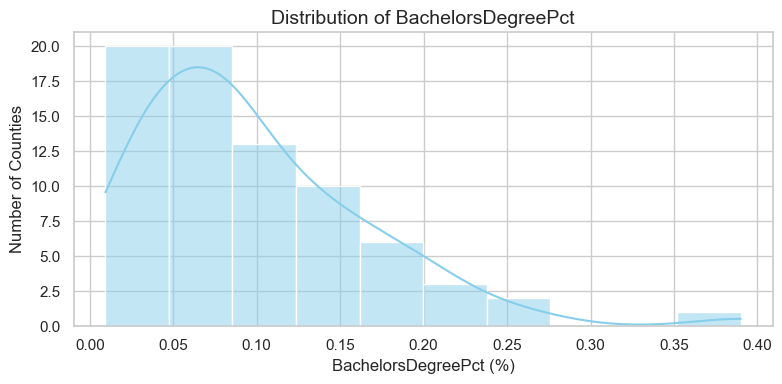

2025-07-22 14:50:20,274 [INFO] 📊 Saved: ar_sec_4_2_1_distribution_highschoolgradpct.png


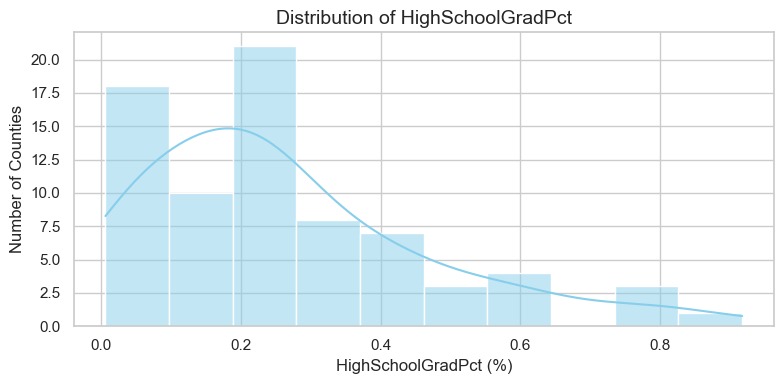

2025-07-22 14:50:20,504 [INFO] 📊 Saved: ar_sec_4_2_1_distribution_povertyrate.png


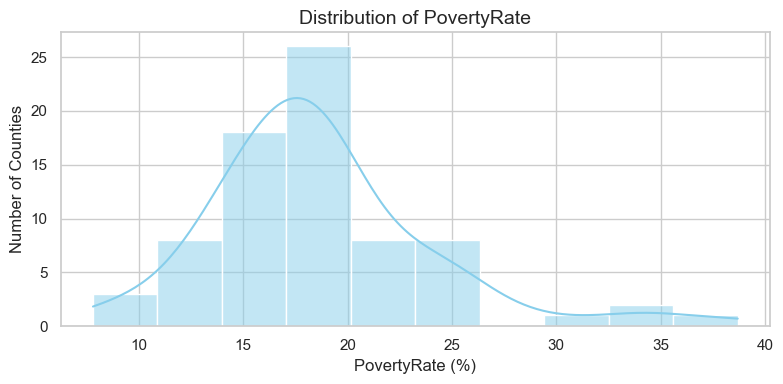

2025-07-22 14:50:20,686 [INFO] 📊 Saved: ar_sec_4_2_1_distribution_unemploymentrate.png


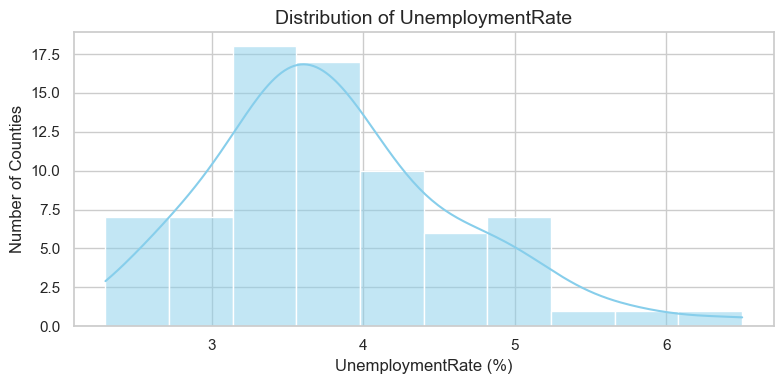

In [13]:
# Section 4.2: Distribution Plots (Histogram + KDE)

# Variables to plot
variables = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate'
]

for var in variables:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_ar_final[var], kde=True, bins=10, color='skyblue')

    plt.title(f"Distribution of {var}", fontsize=14)
    plt.xlabel(f"{var} (%)", fontsize=12)
    plt.ylabel("Number of Counties", fontsize=12)
    plt.tight_layout()

    # Save
    filename = f"ar_sec_4_2_1_distribution_{var.lower()}.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"📊 Saved: {filename}")
    plt.show()


## Section 4.3 Dot Plots

2025-07-22 14:50:21,740 [INFO] [Section 4.3] Saved with NCA highlight: ar_sec_4_3_dotplot_bachelorsdegreepct_nca_highlighted.png


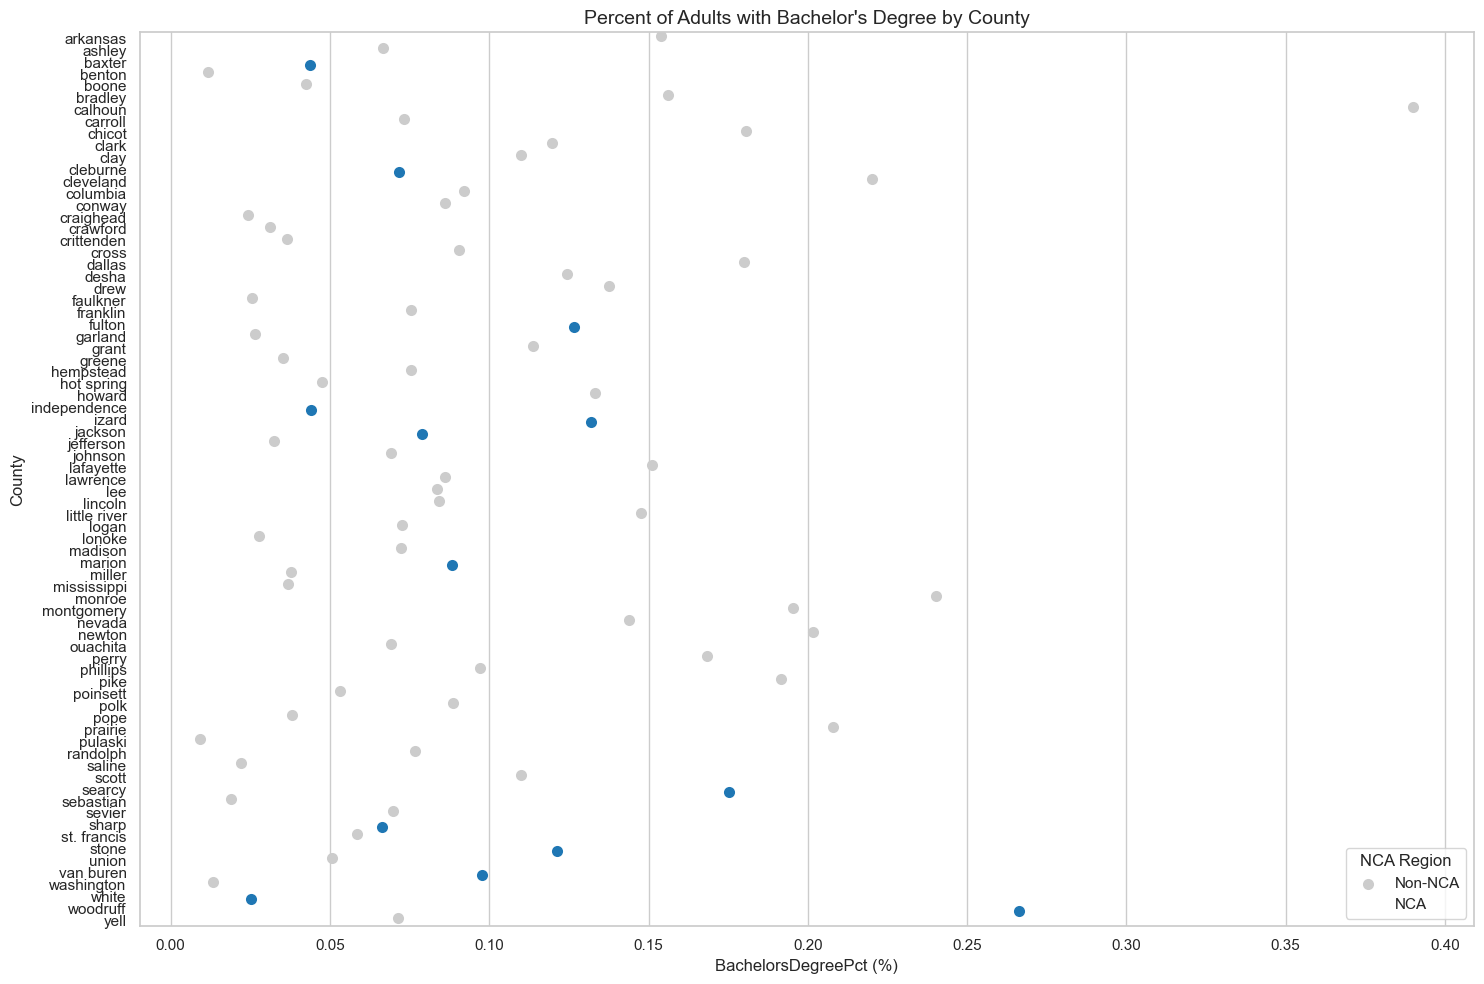

2025-07-22 14:50:23,306 [INFO] [Section 4.3] Saved with NCA highlight: ar_sec_4_3_dotplot_highschoolgradpct_nca_highlighted.png


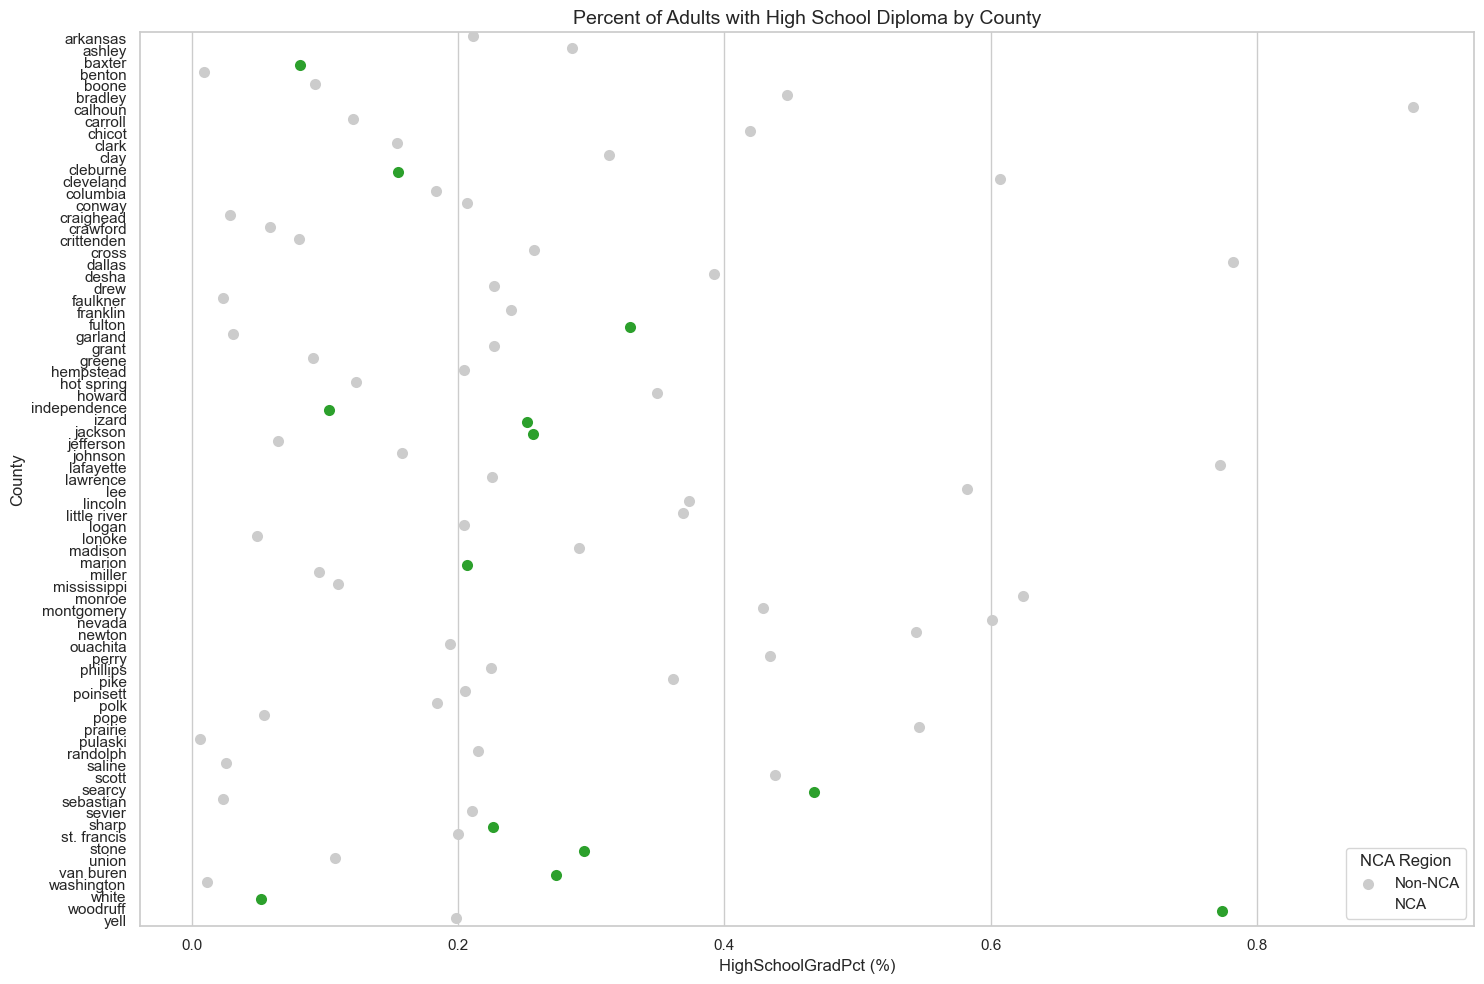

2025-07-22 14:50:24,636 [INFO] [Section 4.3] Saved with NCA highlight: ar_sec_4_3_dotplot_povertyrate_nca_highlighted.png


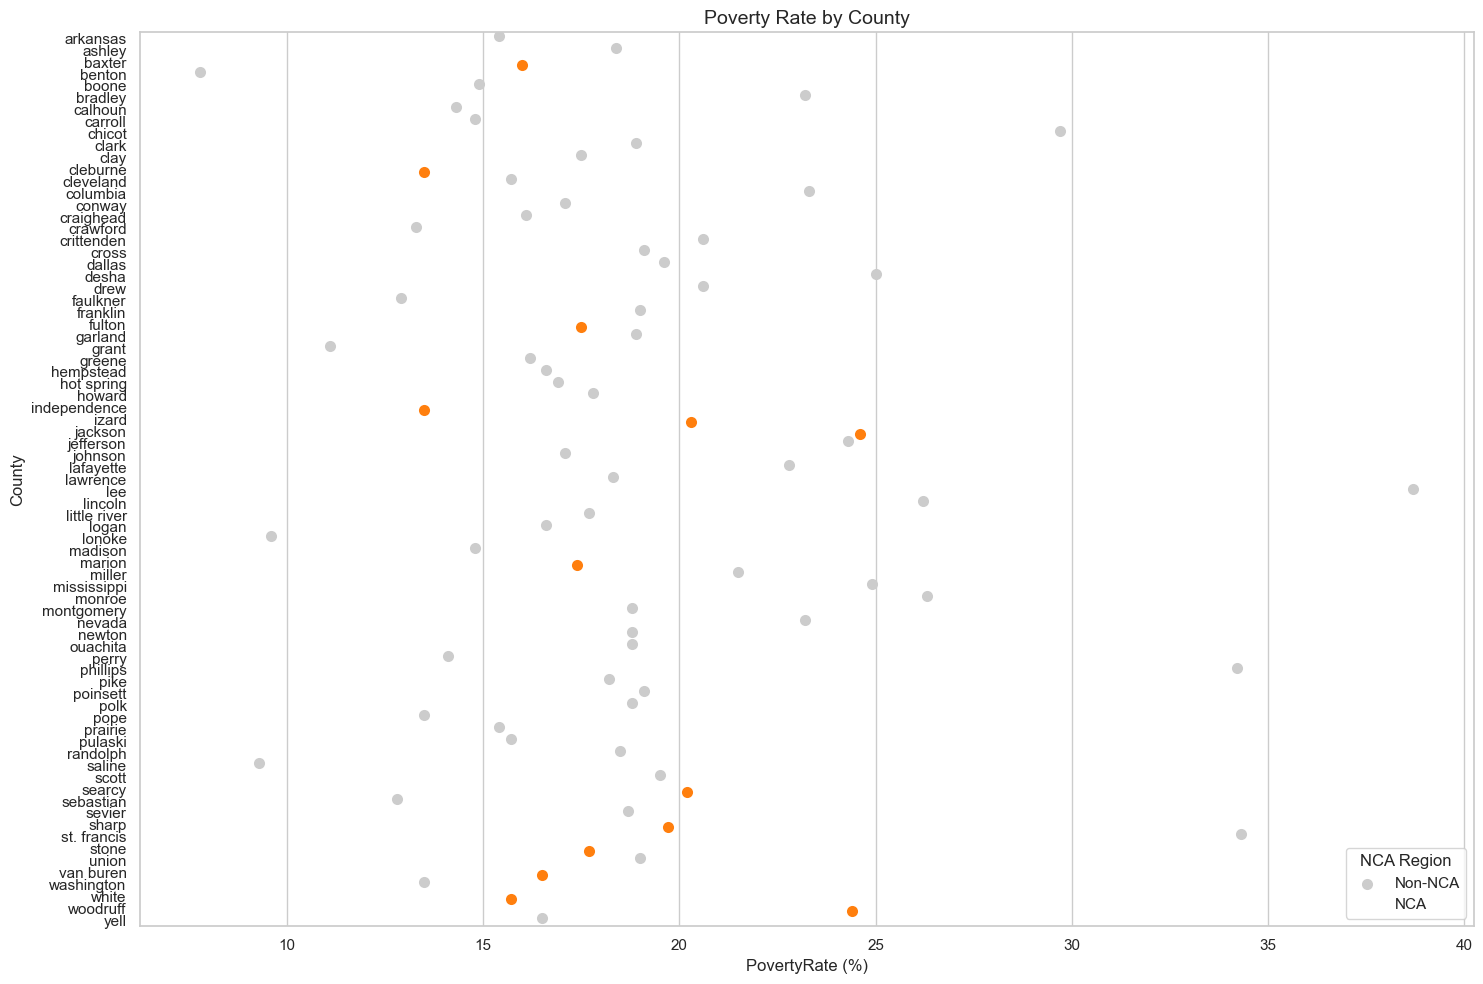

2025-07-22 14:50:25,991 [INFO] [Section 4.3] Saved with NCA highlight: ar_sec_4_3_dotplot_unemploymentrate_nca_highlighted.png


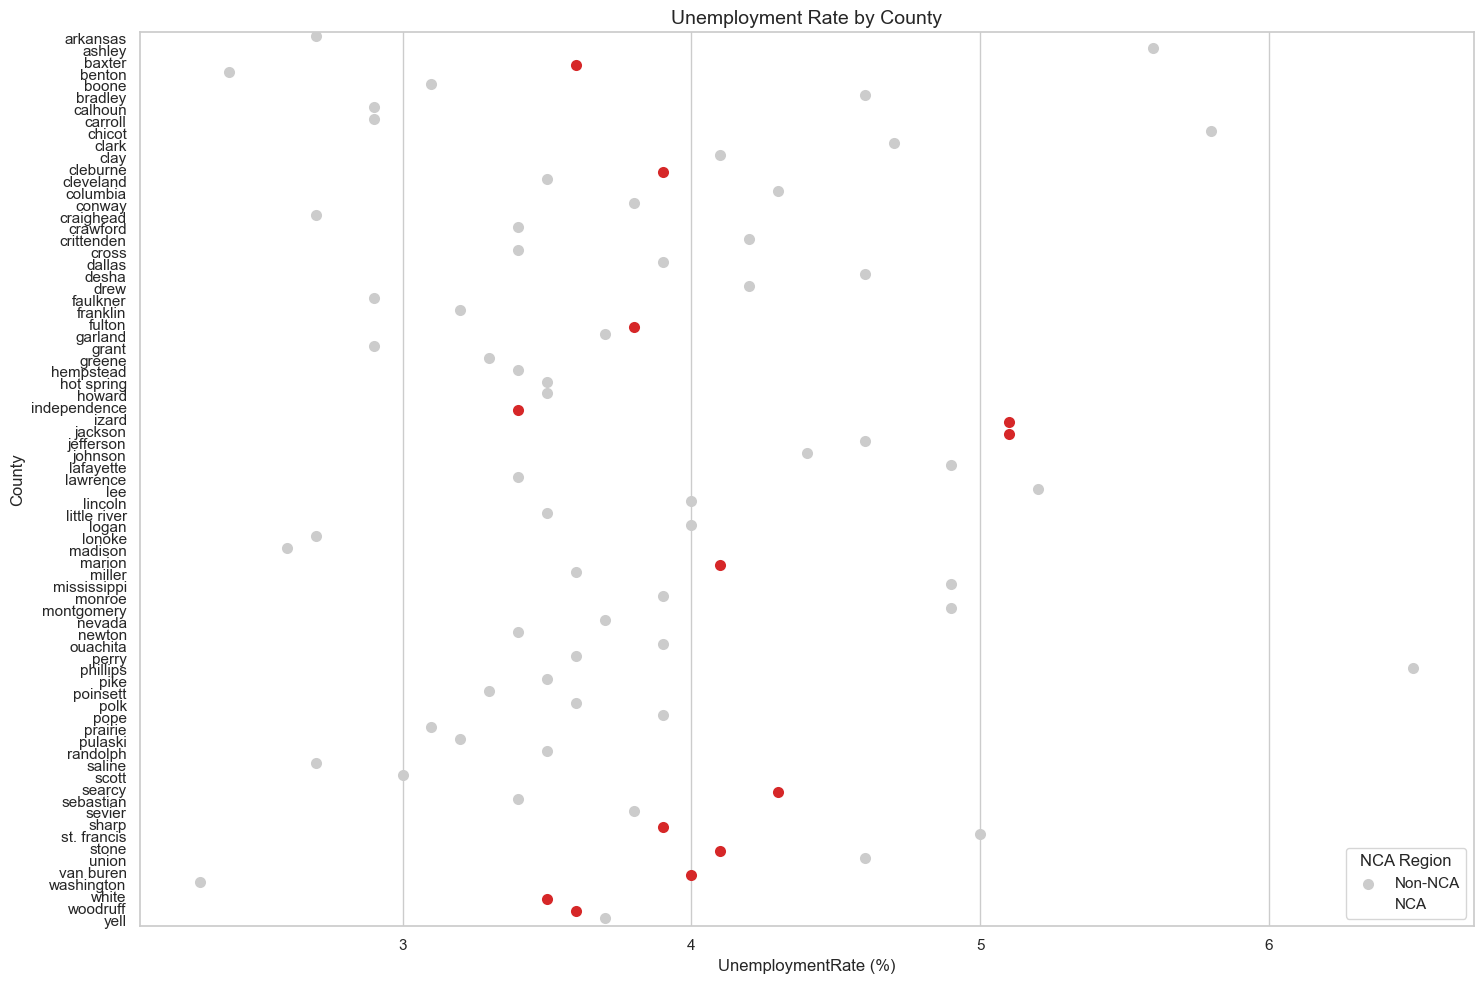

In [14]:
## Section 4.3 Dot Plots
# Section 4.3: Dot Plots by County for Key Indicators

dot_vars = {
    "BachelorsDegreePct": "Percent of Adults with Bachelor's Degree by County",
    "HighSchoolGradPct": "Percent of Adults with High School Diploma by County",
    "PovertyRate": "Poverty Rate by County",
    "UnemploymentRate": "Unemployment Rate by County"
}

for var, title in dot_vars.items():
    df_plot = df_ar_final.reset_index().sort_values('county')  # Alphabetical sort by county name

    plt.figure(figsize=(15, 10))
    sns.stripplot(
        y='county',
        x=var,
        data=df_plot,
        hue='IsNCA',
        palette={0: '#cccccc', 1: variable_colors[var]},  # Gray for Non-NCA, colored for NCA
        size=8,
        jitter=False,
        dodge=True
    )

    plt.title(title, fontsize=14)
    plt.xlabel(f"{var} (%)")
    plt.ylabel("County")
    plt.legend(title="NCA Region", labels=["Non-NCA", "NCA"], loc='lower right')
    plt.tight_layout()

    filename = f"ar_sec_4_3_dotplot_{var.lower()}_nca_highlighted.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"[Section 4.3] Saved with NCA highlight: {filename}")
    plt.show()



## Section 4.4 PairPlot of Variables

2025-07-22 14:50:27,267 [INFO] [Section 4.6] Saved: ar_sec_4_6_pairplot_indicators.png


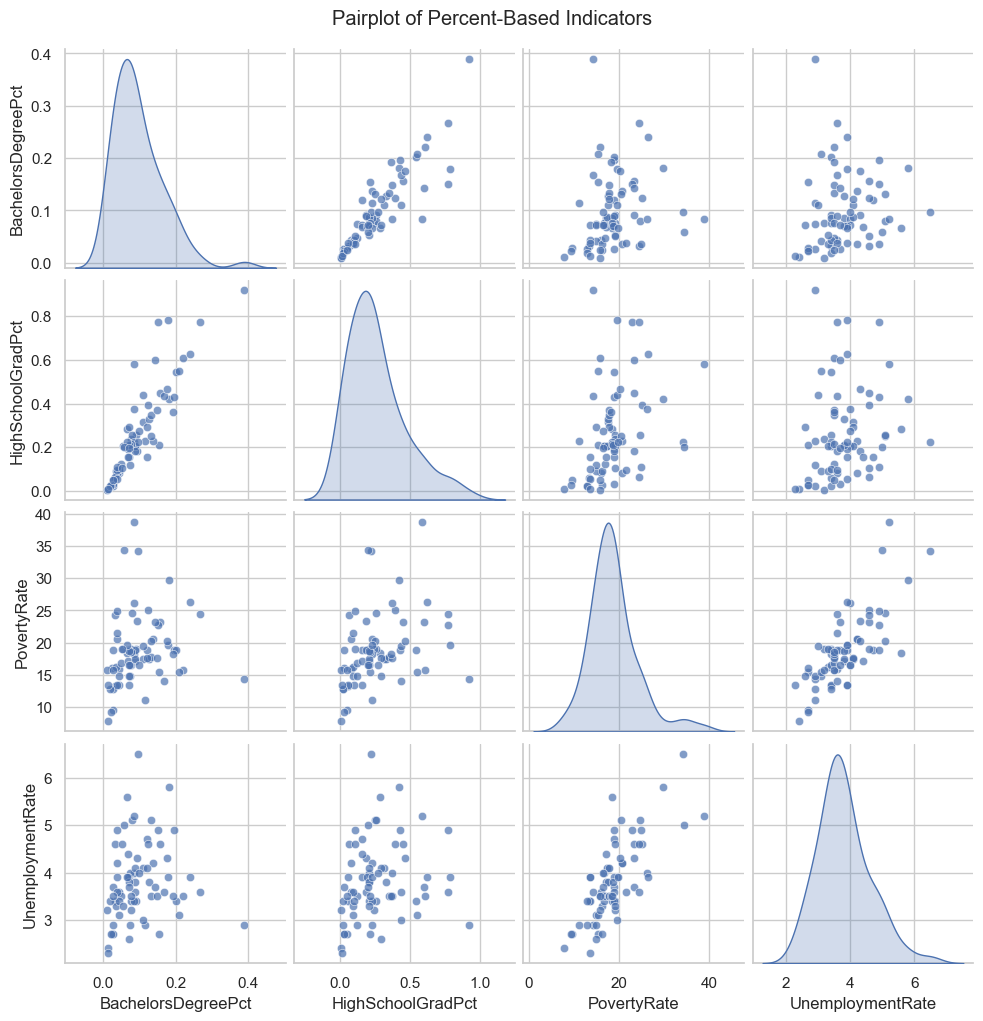

In [15]:
# Section 4.6: Pairplot of All Percent-Based Variables
sns.pairplot(df_ar_final.reset_index(), vars=[
    'BachelorsDegreePct', 'HighSchoolGradPct', 'PovertyRate', 'UnemploymentRate'
], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.7})

plt.suptitle("Pairplot of Percent-Based Indicators", y=1.02)
filename = "ar_sec_4_6_pairplot_indicators.png"
plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
logging.info(f"[Section 4.6] Saved: {filename}")
plt.show()



## Section 4.5 Correlation HeatMap

2025-07-22 14:50:27,723 [INFO] [Section 4.5] Saved: ar_sec_4_5_correlation_heatmap.png


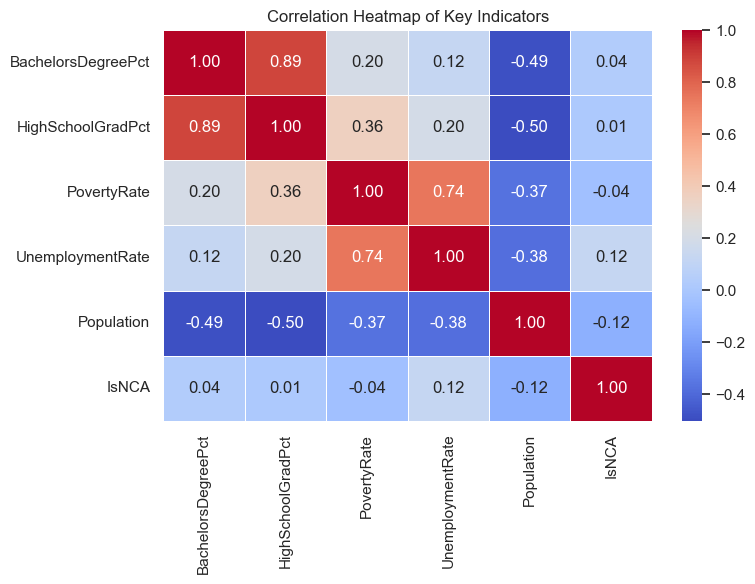

In [16]:
# Section 4.5: Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df_ar_final.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Indicators")
plt.tight_layout()

# Save
filename = "ar_sec_4_5_correlation_heatmap.png"
plt.savefig(image_dir / filename, dpi=300)
logging.info(f"[Section 4.5] Saved: {filename}")
plt.show()


## Section 4.6: Boxplots of Key Indicators

2025-07-22 14:50:27,903 [INFO] [Section 4.7] Saved boxplot with labels: ar_sec_4_7_boxplot_bachelorsdegreepct_labeled.png


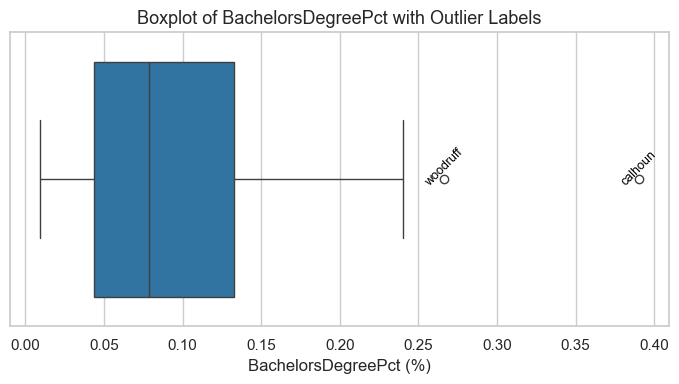

2025-07-22 14:50:28,022 [INFO] [Section 4.7] Saved boxplot with labels: ar_sec_4_7_boxplot_highschoolgradpct_labeled.png


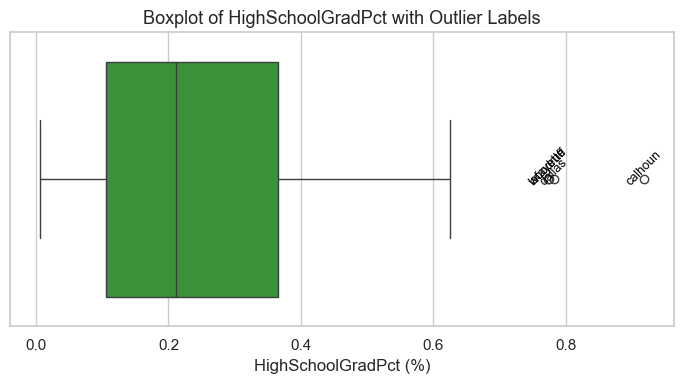

2025-07-22 14:50:28,142 [INFO] [Section 4.7] Saved boxplot with labels: ar_sec_4_7_boxplot_povertyrate_labeled.png


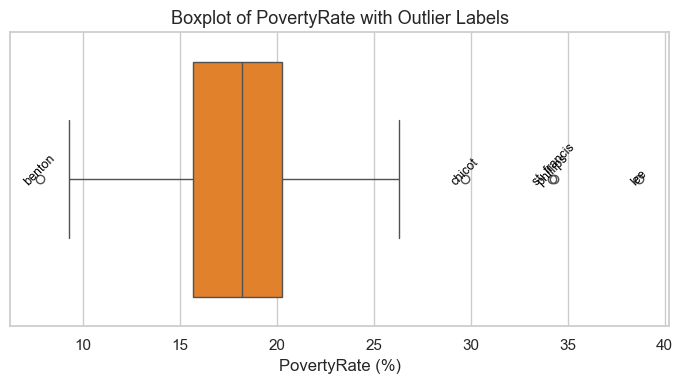

2025-07-22 14:50:28,262 [INFO] [Section 4.7] Saved boxplot with labels: ar_sec_4_7_boxplot_unemploymentrate_labeled.png


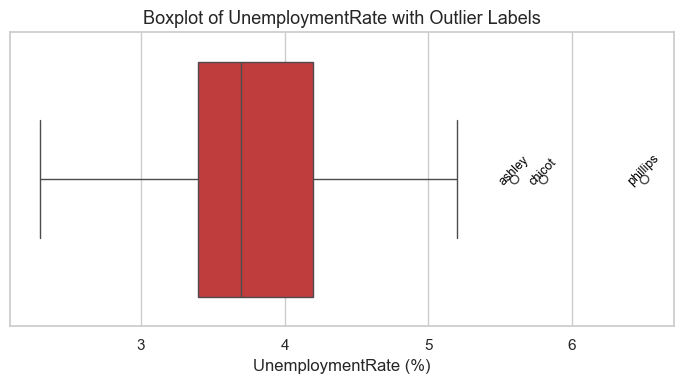

In [17]:
# Section 4.6: Boxplots with Outlier Labels for All Variables

# Boxplots with Outlier Labels and Global Color Mapping

percent_vars = ['BachelorsDegreePct', 'HighSchoolGradPct', 'PovertyRate', 'UnemploymentRate']

def label_outliers_with_color(df, var):
    # Calculate IQR bounds
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

    # Plot with color from global palette
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=var, data=df, color=variable_colors.get(var, 'gray'))

    # Annotate each outlier with the county name
    for i, row in outliers.iterrows():
        plt.text(row[var], 0.02, row.name, fontsize=9, rotation=45, ha='center', color='black')

    # Labels and styling
    plt.title(f"Boxplot of {var} with Outlier Labels", fontsize=13)
    plt.xlabel(f"{var} (%)")
    plt.yticks([])
    plt.tight_layout()

    # Save image
    filename = f"ar_sec_4_7_boxplot_{var.lower()}_labeled.png"
    plt.savefig(image_dir / filename, dpi=300)
    logging.info(f"[Section 4.7] Saved boxplot with labels: {filename}")
    plt.show()

# Run the loop for each variable
for var in percent_vars:
    label_outliers_with_color(df_ar_final, var)




## Section 5: Feature Engineering – County-Level Indices and Flags
To support meaningful interpretation and modeling, a series of derived features and binary flags were engineered to capture structural disparities across Arkansas counties.

🧠 Derived Variable: EducationGap
We calculated an Education Gap by subtracting the percentage of adults with a bachelor’s degree from the percentage with a high school diploma or equivalent. This captures the extent to which postsecondary attainment lags behind basic educational access, offering a simple but insightful lens on educational opportunity gaps. In counties where the gap exceeds 30 percentage points, we flag this as a WideEducationGap condition.

🚩 Binary Risk Flags
Five binary indicators were constructed using evidence-based or policy-relevant thresholds:

Flag	Threshold & Rationale
HighPoverty	Poverty rate > 20% (U.S. Census standard for concentrated poverty)
LowBachelorRate	Bachelor's attainment < 15% (proxy for limited postsecondary access)
HighUnemployment	Unemployment > 6% (elevated vs. state average in post-COVID context)
LargePopulation	Population > 20,000 (reframed as proxy for potential resource strain in service delivery or rural-urban interface zones)
WideEducationGap	Gap > 30 percentage points between high school and bachelor’s rates

📝 Clarification: The LargePopulation flag is not a risk in and of itself, but was retained as a signal for counties that may face resource allocation or infrastructure stress if coupled with other vulnerabilities. This variable may also help flag counties at the rural-urban threshold where dynamics shift.

📊 Composite Vulnerability Score
To synthesize multiple indicators, a Vulnerability Score was created by summing the five binary flags. Each flag contributes equally to the score (weight = 1), yielding a range from 0 to 5.

✅ Rationale for Equal Weights: The decision to assign equal weights reflects an initial exploratory intent—emphasizing transparency and interpretability over complex weighting schemes. This approach avoids overfitting or subjective prioritization during early modeling. Future iterations may explore alternative weighting based on empirical correlations or policy-driven priorities (e.g., weighting poverty more heavily in predictive modeling or funding allocation contexts).

Finally, the composite score was normalized to a 0–1 range to support clustering and modeling in subsequent sections.

In [18]:
# Make a working copy of final dataset
df_fe_ar = df_ar_final.copy()
# Save the working copy
df_fe_ar.to_csv(output_dir / "ar_final_working_copy.csv", index=True)
logging.info("Working copy of final dataset saved as: ar_final_working_copy.csv")
# Display completion message
print("Working copy of final dataset saved as: ar_final_working_copy.csv")


2025-07-22 14:50:28,295 [INFO] Working copy of final dataset saved as: ar_final_working_copy.csv
Working copy of final dataset saved as: ar_final_working_copy.csv


### Section 5.1: Derived Variables

In [19]:
# Section 5.1 – Derived Variables

# Education Gap = HighSchoolGradPct - BachelorsDegreePct
df_fe_ar['EducationGap'] = df_fe_ar['HighSchoolGradPct'] - df_fe_ar['BachelorsDegreePct']

# Preview the new column
print("🎓 Education Gap added:")
display(df_fe_ar[['HighSchoolGradPct', 'BachelorsDegreePct', 'EducationGap']].round(2))

# Save updated dataset (optional, for checkpoints)
df_fe_ar.to_csv(figures_dir / "ar_sec_5_1_derived.csv")
logging.info("Section 5.1 complete: Derived variable 'EducationGap' added and saved.")


🎓 Education Gap added:


,HighSchoolGradPct,BachelorsDegreePct,EducationGap
county,,,
arkansas,0.21,0.15,0.06
ashley,0.29,0.07,0.22
baxter,0.08,0.04,0.04
benton,0.01,0.01,-0.00
boone,0.09,0.04,0.05
...,...,...,...
van buren,0.27,0.10,0.18
washington,0.01,0.01,-0.00
white,0.05,0.03,0.03


2025-07-22 14:50:28,340 [INFO] Section 5.1 complete: Derived variable 'EducationGap' added and saved.


### Section 5.2: Normalized Features

In [20]:
# Section 5.2 – Normalized Features

# Select the features to normalize
features_to_normalize = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'Population',
    'EducationGap'  # from Section 5.1
]

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform
normalized_array = scaler.fit_transform(df_fe_ar[features_to_normalize])

# Create a new DataFrame with normalized features
normalized_df = pd.DataFrame(
    normalized_array,
    columns=[f"{col}_Norm" for col in features_to_normalize],
    index=df_fe_ar.index
)

# Concatenate with main dataframe
df_fe_ar = pd.concat([df_fe_ar, normalized_df], axis=1)

# Preview
print("Normalized columns added:")
display(df_fe_ar[[f"{col}_Norm" for col in features_to_normalize]].head())

#  Save to CSV
df_fe_ar.to_csv(figures_dir / "ar_sec_5_2_normalized.csv")
logging.info("Section 5.2 complete: Normalized features added and saved.")


Normalized columns added:


,BachelorsDegreePct_Norm,HighSchoolGradPct_Norm,PovertyRate_Norm,UnemploymentRate_Norm,Population_Norm,EducationGap_Norm
county,,,,,,
arkansas,0.379914,0.224488,0.245955,0.095238,0.029507,0.095948
ashley,0.150613,0.306059,0.343042,0.785714,0.034451,0.354723
baxter,0.090319,0.081782,0.265372,0.309524,0.096705,0.064264
benton,0.006383,0.003034,0.000000,0.023810,0.774903,0.000535
boone,0.086649,0.094614,0.229773,0.190476,0.085715,0.085222


2025-07-22 14:50:28,363 [INFO] Section 5.2 complete: Normalized features added and saved.


### Section 5.3: Binary Risk Flags
| Column             | Meaning                                                           |
| ------------------ | -------------------------------------------------------------------------------|
| `HighPoverty`      | Poverty rate > 20% (U.S. Census standard for concentrated poverty)             |
| `LowBachelorRate`  | Bachelor's attainment < 15% (proxy for limited postsecondary access)           |
| `HighUnemployment` | Unemployment > 6% (elevated vs. state average in post-COVID context)           |
| `LargePopulation`  | Population > 20,000 (reframed as proxy for potential resource strain in service delivery or rural-urban interface zones)                                       |
| `WideEducationGap` | Gap > 30 percentage points between high school and bachelor’s rates            |




In [21]:
# Section 5.3 – Binary Flags

# Create threshold-based binary flags
df_fe_ar['HighPoverty'] = (df_fe_ar['PovertyRate'] > 20).astype(int)
df_fe_ar['LowBachelorRate'] = (df_fe_ar['BachelorsDegreePct'] < 15).astype(int)
df_fe_ar['HighUnemployment'] = (df_fe_ar['UnemploymentRate'] > 6).astype(int)
df_fe_ar['LargePopulation'] = (df_fe_ar['Population'] > 20000).astype(int)
df_fe_ar['WideEducationGap'] = (df_fe_ar['EducationGap'] > 30).astype(int)

# Preview flags
flag_cols = ['HighPoverty', 'LowBachelorRate', 'HighUnemployment', 'LargePopulation', 'WideEducationGap']
print("Binary Flags:")
display(df_fe_ar[flag_cols])

# Save
df_fe_ar.to_csv(output_dir / "ar_section5_3_flags.csv")
logging.info("Section 5.3 complete: Binary flags added and saved.")

# Section 5.3 Summary – Binary Flag Overview

# 1. Count how many counties meet each condition
flag_summary = df_fe_ar[flag_cols].sum().to_frame(name='Count of Counties')
flag_summary['% of Counties'] = (flag_summary['Count of Counties'] / df_fe_ar.shape[0] * 100).round(1)

# 2. Add a "TotalRiskFlags" column per county
df_fe_ar['TotalRiskFlags'] = df_fe_ar[flag_cols].sum(axis=1)

# 3. Preview counties with highest flag counts
top_flagged = df_fe_ar[['TotalRiskFlags']].sort_values(by='TotalRiskFlags', ascending=False)

# Display summary
print("Summary: Number of Counties Meeting Each Flag Condition")
display(flag_summary)

print("\n Counties with Highest Number of Flags")
display(top_flagged)

# Save
flag_summary.to_csv(figures_dir / "ar_sec_5_3_flag_summary.csv")
top_flagged.to_csv(figures_dir / "ar_sec_5_3_county_flag_totals.csv")
logging.info("Section 5.3 summary tables saved.")



Binary Flags:


,HighPoverty,LowBachelorRate,HighUnemployment,LargePopulation,WideEducationGap
county,,,,,
arkansas,0,1,0,0,0
ashley,0,1,0,0,0
baxter,0,1,0,1,0
benton,0,1,0,1,0
boone,0,1,0,1,0
...,...,...,...,...,...
van buren,0,1,0,0,0
washington,0,1,0,1,0
white,0,1,0,1,0


2025-07-22 14:50:28,385 [INFO] Section 5.3 complete: Binary flags added and saved.
Summary: Number of Counties Meeting Each Flag Condition


,Count of Counties,% of Counties
HighPoverty,20,26.7
LowBachelorRate,75,100.0
HighUnemployment,1,1.3
LargePopulation,33,44.0
WideEducationGap,0,0.0



 Counties with Highest Number of Flags


,TotalRiskFlags
county,
jefferson,3
crittenden,3
columbia,3
mississippi,3
miller,3
...,...
scott,1
sharp,1
sevier,1


2025-07-22 14:50:28,395 [INFO] Section 5.3 summary tables saved.


### Section 5.4: Create Composite Economic Vulnerability Score

In [22]:
# Section 5.4 – Composite Vulnerability Score

# Step 1: Define weights (equal weight for now; you can adjust if needed)
weights = {
    "HighPoverty": 1,
    "LowBachelorRate": 1,
    "HighUnemployment": 1,
    "LargePopulation": 1,
    "WideEducationGap": 1
}

# Step 2: Compute weighted score
df_fe_ar['VulnerabilityScore'] = sum(df_fe_ar[flag] * weight for flag, weight in weights.items())

# Optional: Normalize to 0–1 range using MinMaxScaler
scaler = MinMaxScaler()
df_fe_ar['VulnerabilityScoreNorm'] = scaler.fit_transform(df_fe_ar[['VulnerabilityScore']])

# Step 3: Preview the score table
print("County-Level Composite Vulnerability Score:")
display(df_fe_ar[['VulnerabilityScore', 'VulnerabilityScoreNorm']].sort_values('VulnerabilityScore', ascending=False))

# Save to CSV
df_fe_ar[['VulnerabilityScore', 'VulnerabilityScoreNorm']].to_csv(figures_dir / "ar_section5_4_composite_scores.csv")
logging.info("Section 5.4 composite scores saved.")


County-Level Composite Vulnerability Score:


,VulnerabilityScore,VulnerabilityScoreNorm
county,,
jefferson,3,1.0
crittenden,3,1.0
columbia,3,1.0
mississippi,3,1.0
miller,3,1.0
...,...,...
scott,1,0.0
sharp,1,0.0
sevier,1,0.0


2025-07-22 14:50:28,417 [INFO] Section 5.4 composite scores saved.


## Section 6.1 – KMeans Clustering

Silhouette Score (k=3): 0.420
Average Feature Values per Cluster:


,BachelorsDegreePct_Norm,HighSchoolGradPct_Norm,PovertyRate_Norm,UnemploymentRate_Norm,EducationGap_Norm
ClusterLabel,,,,,
0,0.156,0.168,0.291,0.303,0.150
1,0.520,0.695,0.377,0.307,0.698
2,0.289,0.389,0.593,0.657,0.391


2025-07-22 14:50:28,847 [INFO] [Section 6.2] Saved: section6_1_kmeans_clusters_scatter.png


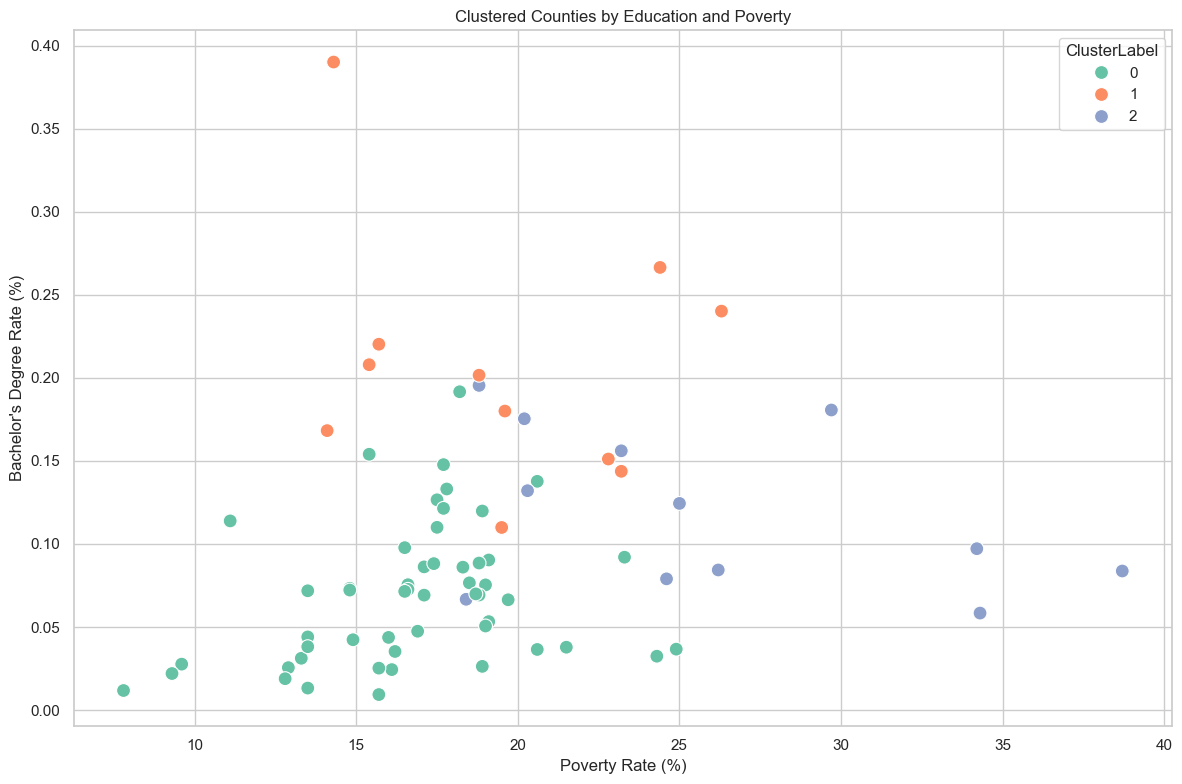

2025-07-22 14:50:28,927 [INFO] Cluster summary saved to CSV.
2025-07-22 14:50:28,928 [INFO] Section 6.1 complete: KMeans clustering with k=3. Saved to CSV.


In [23]:
# Section 6.1 – KMeans Clustering
# Select normalized features to cluster on
cluster_features = [
    'BachelorsDegreePct_Norm',
    'HighSchoolGradPct_Norm',
    'PovertyRate_Norm',
    'UnemploymentRate_Norm',
    'EducationGap_Norm'
]

X = df_fe_ar[cluster_features]

# Choose number of clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
df_fe_ar['ClusterLabel'] = kmeans.fit_predict(X)

# Evaluate clustering quality
sil_score = silhouette_score(X, df_fe_ar['ClusterLabel'])
print(f"Silhouette Score (k={k}): {sil_score:.3f}")

# Get average values by cluster
cluster_summary = df_fe_ar.groupby('ClusterLabel')[cluster_features].mean().round(3)

print("Average Feature Values per Cluster:")
display(cluster_summary)

# Plot each cluster on 2D projection (Poverty vs. Bachelors)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_fe_ar,
    x='PovertyRate',
    y='BachelorsDegreePct',
    hue='ClusterLabel',
    palette='Set2',
    s=100
)

plt.title("Clustered Counties by Education and Poverty")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Bachelor's Degree Rate (%)")
plt.tight_layout()

# Save plot
filename = "section6_1_kmeans_clusters_scatter.png"
plt.savefig(image_dir / filename, dpi=300)
logging.info(f"[Section 6.2] Saved: {filename}")
plt.show()

# Save summary
cluster_summary.to_csv(output_dir / "ar_sec_6_1_cluster_summary.csv")
logging.info("Cluster summary saved to CSV.")

# Save results
df_fe_ar.to_csv(figures_dir / "ar_section6_1_kmeans_clustered.csv")
logging.info(f"Section 6.1 complete: KMeans clustering with k={k}. Saved to CSV.")


## Section 6.2 Interpreting K-Means Clusters

Cluster Profile Summary (raw values):


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,EducationGap,Population,VulnerabilityScore
ClusterLabel,,,,,,,
0,0.07,0.16,16.80,3.57,0.09,54495.62,1.73
1,0.21,0.64,19.46,3.59,0.43,7276.09,1.36
2,0.12,0.36,26.13,5.06,0.24,12826.92,2.00


2025-07-22 14:50:28,954 [INFO] Section 6.2: Cluster profile summary saved.
Counties per Cluster:

▶ High Poverty / Low Degree (52 counties):
  - Arkansas
  - Baxter
  - Benton
  - Boone
  - Carroll
  - Clark
  - Clay
  - Cleburne
  - Columbia
  - Conway
  - Craighead
  - Crawford
  - Crittenden
  - Cross
  - Drew
  - Faulkner
  - Franklin
  - Fulton
  - Garland
  - Grant
  - Greene
  - Hempstead
  - Hot Spring
  - Howard
  - Independence
  - Jefferson
  - Johnson
  - Lawrence
  - Little River
  - Logan
  - Lonoke
  - Madison
  - Marion
  - Miller
  - Mississippi
  - Ouachita
  - Pike
  - Poinsett
  - Polk
  - Pope
  - Pulaski
  - Randolph
  - Saline
  - Sebastian
  - Sevier
  - Sharp
  - Stone
  - Union
  - Van Buren
  - Washington
  - White
  - Yell

▶ Low Poverty / Low Education (12 counties):
  - Ashley
  - Bradley
  - Chicot
  - Desha
  - Izard
  - Jackson
  - Lee
  - Lincoln
  - Montgomery
  - Phillips
  - Searcy
  - St. Francis

▶ Moderate Risk / Moderate Education (11 counties):

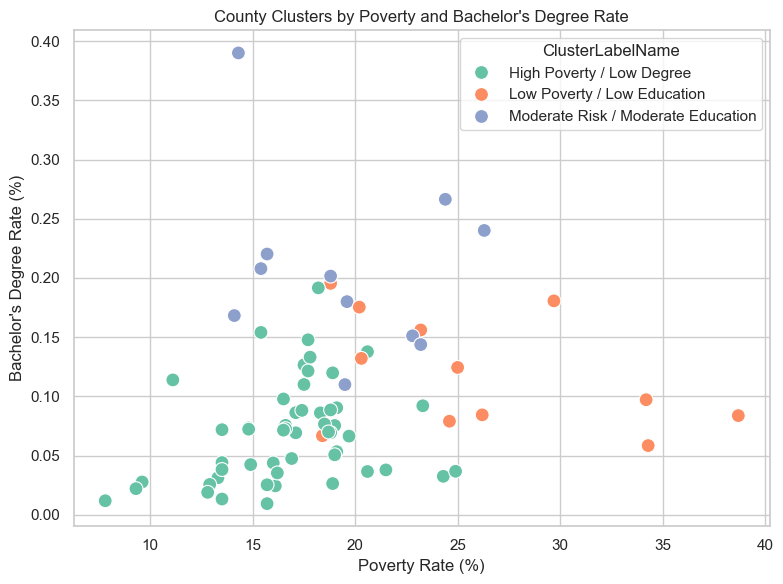

In [24]:
# Cluster profile summary: raw (non-normalized) values
cluster_summary = df_fe_ar.groupby('ClusterLabel')[[
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'EducationGap',
    'Population',
    'VulnerabilityScore'
]].mean().round(2)

print("Cluster Profile Summary (raw values):")
display(cluster_summary)

# Save to CSV
cluster_summary.to_csv(figures_dir / "ar_sec_6_2_cluster_profiles.csv")
logging.info("Section 6.2: Cluster profile summary saved.")


cluster_names = {
    0: "High Poverty / Low Degree",
    1: "Moderate Risk / Moderate Education",
    2: "Low Poverty / Low Education"
}

# Add human-readable cluster label
df_fe_ar['ClusterLabelName'] = df_fe_ar['ClusterLabel'].map(cluster_names)

# List counties by cluster
clustered_counties = df_fe_ar.reset_index().groupby('ClusterLabelName')['county'].apply(list)

print("Counties per Cluster:")
for label, counties in clustered_counties.items():
    print(f"\n▶ {label} ({len(counties)} counties):")
    for c in counties:
        print(f"  - {c.title()}")

        # Save as plain text
with open(figures_dir / "ar_sec_6_2_counties_per_cluster.txt", "w") as f:
    for label, counties in clustered_counties.items():
        f.write(f"{label} ({len(counties)} counties):\n")
        for c in counties:
            f.write(f" - {c.title()}\n")
        f.write("\n")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_fe_ar.reset_index(),
    x='PovertyRate',
    y='BachelorsDegreePct',
    hue='ClusterLabelName',
    palette='Set2',
    s=100
)
plt.title("County Clusters by Poverty and Bachelor's Degree Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Bachelor's Degree Rate (%)")
plt.tight_layout()

plt.savefig(image_dir / "ar_sec_6_2_cluster_scatter_named.png", dpi=300)
logging.info("Section 6.2 scatterplot with named clusters saved.")
plt.show()


## Section 6.3 – Supervised Learning: Predicting Cluster Membership

Cross-Validation Accuracy Scores: [0.93333333 0.93333333 0.93333333 0.93333333 0.86666667]
Mean CV Accuracy: 0.920
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      1.00      1.00         3
           2       1.00      0.75      0.86         4

    accuracy                           0.96        23
   macro avg       0.98      0.92      0.94        23
weighted avg       0.96      0.96      0.95        23

Confusion Matrix:
[[16  0  0]
 [ 0  3  0]
 [ 1  0  3]]
2025-07-22 14:50:29,906 [INFO] ✅ Saved confusion matrix plot: ar_sec_6_3_confusion_matrix.png


<Figure size 800x600 with 0 Axes>

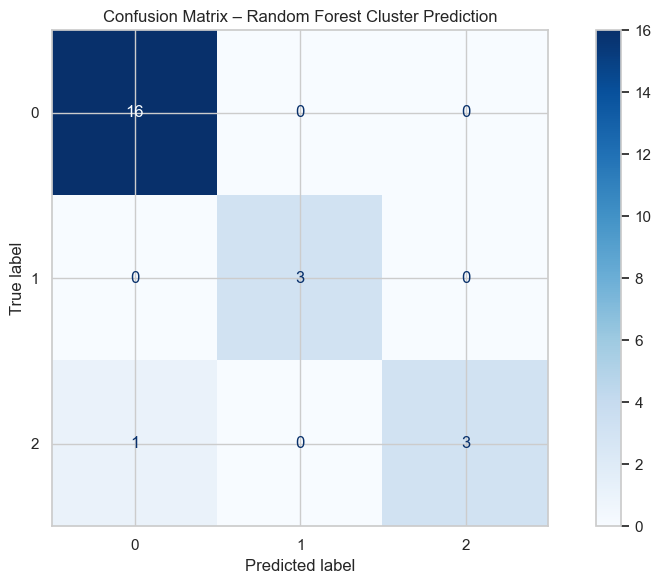

2025-07-22 14:50:30,305 [INFO] [Section 6.3] Feature importance plot saved: ar_sec_6_3_feature_importance.png


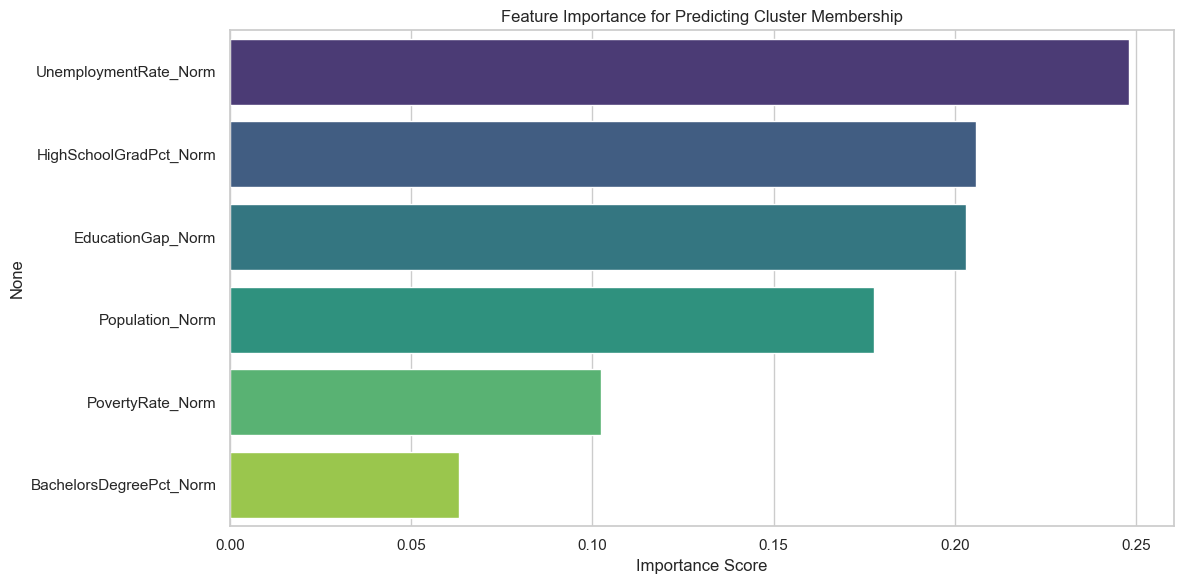

2025-07-22 14:50:30,388 [INFO] Section 6.3 complete: Predictions saved with comparison column.


In [25]:
# Use normalized features from feature engineering
features = [
    'BachelorsDegreePct_Norm',
    'HighSchoolGradPct_Norm',
    'PovertyRate_Norm',
    'UnemploymentRate_Norm',
    'EducationGap_Norm',
    'Population_Norm'
]

X = df_fe_ar[features]
y = df_fe_ar['ClusterLabel']  # Target from K-Means clustering

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Cross-Validation for Model Robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.3f}")

# Predict
y_pred = rf_model.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Create and display confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Random Forest Cluster Prediction")
plt.tight_layout()

# Save plot
filename = "ar_sec_6_3_confusion_matrix.png"
plt.savefig(image_dir / filename, dpi=300)
logging.info(f"✅ Saved confusion matrix plot: {filename}")
plt.show()

# Display feature importances
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance for Predicting Cluster Membership")
plt.xlabel("Importance Score")
plt.tight_layout()

filename = "ar_sec_6_3_feature_importance.png"
plt.savefig(image_dir / filename, dpi=300)
logging.info(f"[Section 6.3] Feature importance plot saved: {filename}")
plt.show()

# Save feature importances to CSV
importances.to_csv(figures_dir / "ar_sec_6_3_feature_importance.csv")

df_fe_ar['PredictedClusterLabel'] = rf_model.predict(X)
df_fe_ar['PredictedClusterMatch'] = (df_fe_ar['PredictedClusterLabel'] == df_fe_ar['ClusterLabel']).astype(int)

# Save results
df_fe_ar.to_csv(figures_dir / "ar_sec_6_3_cluster_predictions.csv")
logging.info("Section 6.3 complete: Predictions saved with comparison column.")

cv_df = pd.DataFrame({'Fold': [f'Fold {i+1}' for i in range(5)], 'Accuracy': cv_scores})
cv_df.loc['Mean'] = ['Mean', cv_scores.mean()]
cv_df.to_csv(figures_dir / "ar_sec_6_3_cross_validation_scores.csv", index=False)


2025-07-22 14:50:30,740 [INFO] Section 6.3 decision tree saved.


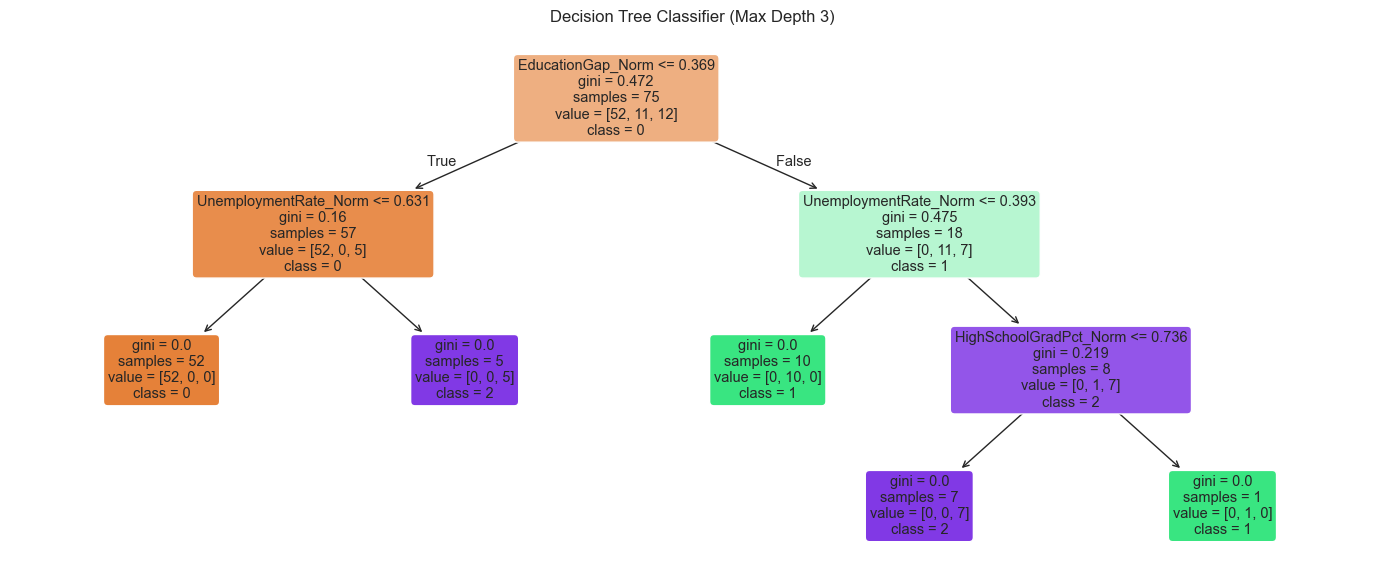

In [26]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)

plt.figure(figsize=(14, 6))
plot_tree(tree, feature_names=features, class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True)
plt.title("Decision Tree Classifier (Max Depth 3)")
plt.tight_layout()

plt.savefig(image_dir / "ar_sec_6_3_decision_tree.png", dpi=300)
logging.info("Section 6.3 decision tree saved.")
plt.show()
